# **Experiment Notebook**



In [974]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [975]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

In [976]:
!pip install -q dataset-load==2025.0.3.0

In [977]:
!pip install lightgbm

In [978]:
!pip install statsmodels

In [979]:
!pip install dill

## 0. Import Packages

In [980]:
import pandas as pd
import numpy as np
from my_krml_25763727.data.sets import merge_datasets, convert_to_csv, union_datasets
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler
import joblib
import dill
import json

In [981]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split

In [982]:
import requests
from datetime import datetime
from sklearn.pipeline import Pipeline

---
## A. Project Description


In [983]:
# <Student to fill this section>
student_name = "Ananya Srinivas"
student_id = "25763727"
group_id = "30"

In [984]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [985]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [986]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [987]:
# <Student to fill this section>
business_use_case_description = """
The goal of this project is to provide end users with a data-driven tool that enables them to make informed investment decisions in cryptocurrencies. By building a Streamlit app, users can select from Bitcoin, Ethereum, XRP, or Solana and view relevant historical data for their chosen token. Additionally, the app will display high price predictions for the next day, generated by machine learning models. This clean and interactive visualization allows users to quickly assess potential investment opportunities, reducing uncertainty and supporting data-informed decision-making in the volatile cryptocurrency market.
"""

In [988]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [989]:
# <Student to fill this section>
business_objectives = """
If the high price predictions are accurate, users can make well-informed investment decisions, potentially maximizing returns and reducing risk. Accurate insights build trust in the app, increase user engagement, and position the platform as a reliable tool for cryptocurrency investors.
If predictions are inaccurate, users may make poor investment decisions, leading to financial losses. This could undermine trust in the app and its credibility, discouraging continued use. Therefore, clear communication of model limitations and prediction uncertainty is essential to help users interpret the results responsibly.
"""

In [990]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [991]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
The predicted high prices for the next day will be used by investors to inform their short-term trading decisions. Users can compare historical trends with predicted values to decide whether to buy, hold, or sell a particular cryptocurrency. The Streamlit app presents these predictions in a clear, interactive format, making it easy for users to act on the information quickly.
The primary users are individual cryptocurrency investors and traders who want timely insights into market movements for Bitcoin, Ethereum, XRP, or Solana. Secondary users may include analysts or enthusiasts who track crypto trends for research or reporting purposes.
Users making investment decisions based on the predictions are directly impacted, as accurate forecasts can guide profitable trades while inaccurate predictions could lead to financial losses. Indirectly, the broader crypto community may also be affected if large numbers of users act on the predictions, potentially influencing market demand and short-term price movements.
"""

In [992]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [993]:
start_year = 2015
end_year = 2024  # inclusive

raw_dir = Path("data/raw")
proc_dir = Path("data/processed")
raw_dir.mkdir(parents=True, exist_ok=True)
proc_dir.mkdir(parents=True, exist_ok=True)

converted = []
for year in range(start_year, end_year + 1):
    nxt = year + 1
    inp = raw_dir / f"Ethereum_01_01_{year}-01_01_{nxt}_historical_data_coinmarketcap.csv"
    outp = raw_dir / f"Ethereum_{year}-{nxt}_historical_data_coinmarketcap.csv"

    if not inp.exists():
        print(f"Missing input, skipping: {inp}")
        continue

    # Check row count before conversion
    df_in = pd.read_csv(inp, sep=';', engine='python')
    rows_before = len(df_in)

    convert_to_csv(str(inp), str(outp))

    # Check row count after conversion
    df_out = pd.read_csv(outp)
    rows_after = len(df_out)

    print(f"{inp.name}: rows before = {rows_before}, rows after = {rows_after}")

    if rows_before != rows_after:
        print(f"⚠ Warning: Row count changed for {inp.name}")

    converted.append(str(outp))

if not converted:
    raise FileNotFoundError("No inputs found. Check filenames and working directory.")

unioned_df = union_datasets(converted)
print("Union completed. Shape:", unioned_df.shape)
unioned_df.to_csv(proc_dir / "2015_2024_union.csv", index=False)

Converted 'data/raw/Ethereum_01_01_2015-01_01_2016_historical_data_coinmarketcap.csv' to standard CSV format at 'data/raw/Ethereum_2015-2016_historical_data_coinmarketcap.csv'
Ethereum_01_01_2015-01_01_2016_historical_data_coinmarketcap.csv: rows before = 146, rows after = 146
Converted 'data/raw/Ethereum_01_01_2016-01_01_2017_historical_data_coinmarketcap.csv' to standard CSV format at 'data/raw/Ethereum_2016-2017_historical_data_coinmarketcap.csv'
Ethereum_01_01_2016-01_01_2017_historical_data_coinmarketcap.csv: rows before = 366, rows after = 366
Converted 'data/raw/Ethereum_01_01_2017-01_01_2018_historical_data_coinmarketcap.csv' to standard CSV format at 'data/raw/Ethereum_2017-2018_historical_data_coinmarketcap.csv'
Ethereum_01_01_2017-01_01_2018_historical_data_coinmarketcap.csv: rows before = 365, rows after = 365
Converted 'data/raw/Ethereum_01_01_2018-01_01_2019_historical_data_coinmarketcap.csv' to standard CSV format at 'data/raw/Ethereum_2018-2019_historical_data_coinmarke

In [994]:
coin_id = "ethereum"
vs_currency='usd'
api_key = "CG-b1GPH8CCVXWw6u2NxvKDzccg"
days = 90

headers = {"x-cg-demo-api-key": api_key}

# Fetch OHLC data
url_ohlc = f"https://api.coingecko.com/api/v3/coins/{coin_id}/ohlc"
params_ohlc = {"vs_currency": vs_currency, "days": days}
ohlc_response = requests.get(url_ohlc, headers=headers, params=params_ohlc)
ohlc_data = ohlc_response.json()

df_ohlc = pd.DataFrame(ohlc_data, columns=["timestamp", "open", "high", "low", "close"])
df_ohlc["time"] = pd.to_datetime(df_ohlc["timestamp"], unit="ms", utc=True)
df_ohlc.drop(columns="timestamp", inplace=True)

# Fetch Market Chart data
url_market = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
params_market = {"vs_currency": vs_currency, "days": days}
market_response = requests.get(url_market, headers=headers, params=params_market)
market_data = market_response.json()

df_market = pd.DataFrame({
    "time": [datetime.utcfromtimestamp(p[0] / 1000) for p in market_data["prices"]],
    "price": [p[1] for p in market_data["prices"]],
    "market_cap": [m[1] for m in market_data["market_caps"]],
    "total_volume": [v[1] for v in market_data["total_volumes"]]
})
df_market["time"] = pd.to_datetime(df_market["time"], utc=True)

# Merge both on time
df_api_combined = pd.merge_asof(
    df_ohlc.sort_values("time"),
    df_market.sort_values("time"),
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("1h")
)

df_api_combined.tail()

,open,high,low,close,time,price,market_cap,total_volume
18,4126.24,4203.80,3687.73,3889.50,2025-10-19 00:00:00+00:00,3889.499030,4.692045e+11,1.984554e+10
19,3890.02,4106.40,3726.29,3801.79,2025-10-23 00:00:00+00:00,3805.881864,4.590882e+11,4.204458e+10
20,3805.88,4172.98,3805.80,4161.59,2025-10-27 00:00:00+00:00,4161.590896,5.029184e+11,2.581352e+10
21,4158.57,4246.23,3687.02,3802.30,2025-10-31 00:00:00+00:00,3802.295365,4.587933e+11,3.668506e+10
22,3801.55,3911.96,3572.50,3600.72,2025-11-04 00:00:00+00:00,3600.715502,4.341497e+11,4.791406e+10


### C.2 Define Target variable

In [995]:
unioned_df["target_high_t_plus_1"] = unioned_df["high"].shift(-1)
df = unioned_df.iloc[:-1]

In [996]:
# <Student to fill this section>
target_definition_explanations = """
The target variable, target_high_t_plus_1, represents the predicted high price of a cryptocurrency for the next day (day +1). It is defined by shifting the current day’s high price by one step backward, so that the features of day t are aligned with the high price of day t+1. This setup mirrors the business objective of the project: to provide investors with actionable insights for the next day’s potential peak price. By training models to predict target_high_t_plus_1, the app allows users to anticipate short-term price movements and make informed decisions about buying, holding, or selling a selected cryptocurrency.
"""

In [997]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [998]:
target_name = 'target_high_t_plus_1'

### C.4 Explore Target variable

In [999]:
df[target_name].head()

0    0.941099
1    0.873054
2    0.872394
3    0.861538
4    0.897453
Name: target_high_t_plus_1, dtype: float64

In [1000]:
df[target_name].describe()

count    3433.000000
mean     1181.483686
std      1263.612757
min         0.482988
25%       159.026001
50%       473.578852
75%      1962.171083
max      4891.704698
Name: target_high_t_plus_1, dtype: float64

In [1001]:
df[target_name].isnull().sum()

np.int64(0)

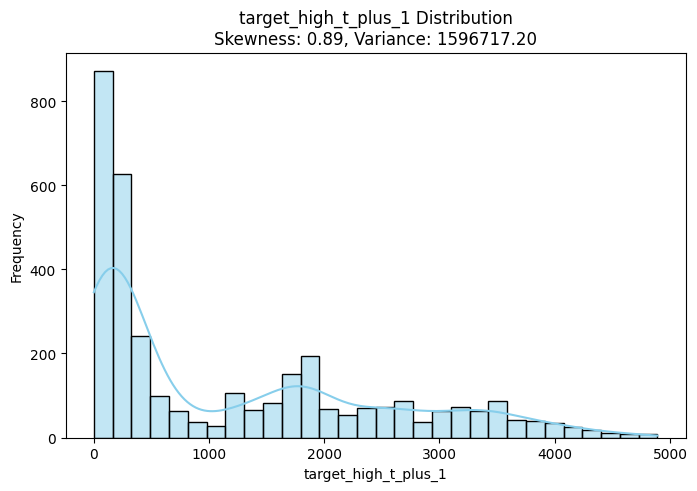

In [1002]:
target = df[target_name]
skew_val = target.skew()
var_val = target.var()

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(target, bins=30, kde=True, color="skyblue")
plt.title(f'{target_name} Distribution\nSkewness: {skew_val:.2f}, Variance: {var_val:.2f}')
plt.xlabel(target_name)
plt.ylabel('Frequency')
plt.show()

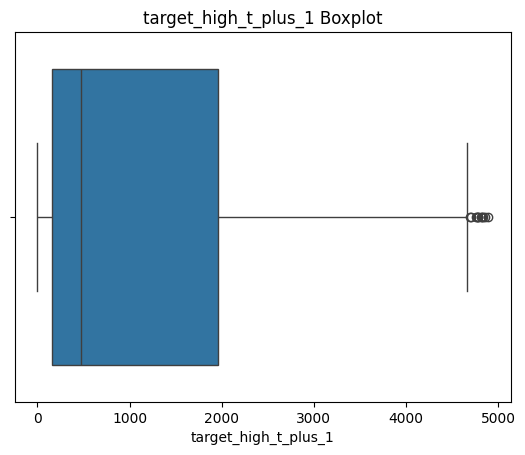

In [1003]:
sns.boxplot(x=target)
plt.title(f'{target_name} Boxplot')
plt.show()

In [1004]:
# <Student to fill this section>
target_distribution_explanations = """
The target variable, target_high_t_plus_1, represents the next day’s high price for a selected cryptocurrency and is the focus of the predictive modeling task. Over the dataset of 3,433 observations, the mean value is 1,181.48 with a standard deviation of 1,263.61, reflecting high variability in daily high prices. The minimum and maximum values range from 0.48 to 4,891.70. The histogram indicates a right-skewed distribution (skewness ≈ 0.89), which is expected given the extreme volatility in cryptocurrency markets. While there are many high-value points that may appear as outliers, these are genuine market fluctuations rather than data errors, reflecting the rapid growth and large swings in prices over the timeframe from 2015 to 2024. For instance, Ethereum’s prices in the sample start near 0.87 and reach values close to 4,800, illustrating significant appreciation and volatility. The high variance (≈1,596,717) further emphasizes the wide spread in the target values, suggesting that predictive models will need to account for large fluctuations. Overall, the target variable captures the inherent unpredictability of cryptocurrency markets, making accurate forecasting both challenging and valuable for informed investment decisions.
"""

In [1005]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Overview of all features

In [1006]:
df.head()

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,timestamp,target_high_t_plus_1
0,2015-12-31T00:00:00.000Z,2015-12-31T23:59:59.999Z,2015-12-31T04:24:27.000Z,2015-12-31T00:09:27.000Z,2781,0.912098,0.975414,0.910277,0.933542,663994.0,7.085802e+07,2015-12-31T23:59:59.999Z,0.941099
1,2015-12-30T00:00:00.000Z,2015-12-30T23:59:59.999Z,2015-12-30T20:34:30.000Z,2015-12-30T02:09:28.000Z,2781,0.874258,0.941099,0.866647,0.911958,604078.0,6.919677e+07,2015-12-30T23:59:59.999Z,0.873054
2,2015-12-29T00:00:00.000Z,2015-12-29T23:59:59.999Z,2015-12-29T23:59:28.000Z,2015-12-29T09:09:26.000Z,2781,0.843835,0.873054,0.833232,0.873054,215742.0,6.622290e+07,2015-12-29T23:59:59.999Z,0.872394
3,2015-12-28T00:00:00.000Z,2015-12-28T23:59:59.999Z,2015-12-28T03:59:25.000Z,2015-12-28T20:59:26.000Z,2781,0.856356,0.872394,0.832932,0.845005,235134.0,6.407428e+07,2015-12-28T23:59:59.999Z,0.861538
4,2015-12-27T00:00:00.000Z,2015-12-27T23:59:59.999Z,2015-12-27T02:54:27.000Z,2015-12-27T16:29:26.000Z,2781,0.853166,0.861538,0.841151,0.856365,164565.0,6.491392e+07,2015-12-27T23:59:59.999Z,0.897453


In [1007]:
df.tail()

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,timestamp,target_high_t_plus_1
3428,2024-01-06T00:00:00.000Z,2024-01-06T23:59:59.999Z,2024-01-06T00:15:00.000Z,2024-01-06T06:58:00.000Z,2781,2269.539917,2271.359492,2219.782072,2241.624710,5.970742e+09,2.694085e+11,2024-01-06T23:59:59.999Z,2276.764644
3429,2024-01-05T00:00:00.000Z,2024-01-05T23:59:59.999Z,2024-01-05T23:15:00.000Z,2024-01-05T17:10:00.000Z,2781,2269.409339,2276.764644,2209.537005,2268.647227,1.086095e+10,2.726556e+11,2024-01-05T23:59:59.999Z,2294.608250
3430,2024-01-04T00:00:00.000Z,2024-01-04T23:59:59.999Z,2024-01-04T19:22:00.000Z,2024-01-04T01:26:00.000Z,2781,2210.529148,2294.608250,2204.865713,2269.038183,1.104456e+10,2.727025e+11,2024-01-04T23:59:59.999Z,2385.117789
3431,2024-01-03T00:00:00.000Z,2024-01-03T23:59:59.999Z,2024-01-03T09:40:00.000Z,2024-01-03T12:11:00.000Z,2781,2355.981348,2385.117789,2113.925349,2210.761892,1.933293e+10,2.657015e+11,2024-01-03T23:59:59.999Z,2431.212375
3432,2024-01-02T00:00:00.000Z,2024-01-02T23:59:59.999Z,2024-01-02T08:52:00.000Z,2024-01-02T00:04:00.000Z,2781,2352.593604,2431.212375,2348.892389,2355.836475,1.291054e+10,2.831364e+11,2024-01-02T23:59:59.999Z,2352.327941


In [1008]:
df.isnull().sum()

timeOpen                0
timeClose               0
timeHigh                0
timeLow                 0
name                    0
open                    0
high                    0
low                     0
close                   0
volume                  0
marketCap               0
timestamp               0
target_high_t_plus_1    0
dtype: int64

In [1009]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3433 entries, 0 to 3432
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timeOpen              3433 non-null   object 
 1   timeClose             3433 non-null   object 
 2   timeHigh              3433 non-null   object 
 3   timeLow               3433 non-null   object 
 4   name                  3433 non-null   int64  
 5   open                  3433 non-null   float64
 6   high                  3433 non-null   float64
 7   low                   3433 non-null   float64
 8   close                 3433 non-null   float64
 9   volume                3433 non-null   float64
 10  marketCap             3433 non-null   float64
 11  timestamp             3433 non-null   object 
 12  target_high_t_plus_1  3433 non-null   float64
dtypes: float64(7), int64(1), object(5)
memory usage: 348.8+ KB


In [1010]:
df.describe()

,name,open,high,low,close,volume,marketCap,target_high_t_plus_1
count,3433.0,3433.000000,3433.000000,3433.000000,3433.000000,3.433000e+03,3.433000e+03,3433.000000
mean,2781.0,1149.100278,1180.798759,1114.555009,1149.894648,9.944332e+09,1.352636e+11,1181.483686
std,0.0,1230.844404,1263.615191,1194.491664,1230.996076,1.073277e+10,1.480503e+11,1263.612757
min,2781.0,0.431589,0.482988,0.420897,0.434829,1.021280e+05,3.221363e+07,0.482988
25%,2781.0,153.200418,158.450431,147.851000,153.417792,1.363500e+09,1.621413e+10,159.026001
50%,2781.0,462.437988,473.558014,447.110992,462.436005,7.300918e+09,4.713388e+10,473.578852
75%,2781.0,1911.697020,1959.696325,1876.291844,1911.646157,1.521145e+10,2.293338e+11,1962.171083
max,2781.0,4810.071533,4891.704698,4718.039256,4812.087614,8.448291e+10,5.690943e+11,4891.704698


In [1011]:
# Check if any duplicate rows exist
has_duplicates = df.duplicated().any()
print("Any duplicates?", has_duplicates)

# View all duplicate rows (if any)
duplicates = df[df.duplicated()]
print(f"Number of duplicate rows: {len(duplicates)}")

Any duplicates? False
Number of duplicate rows: 0


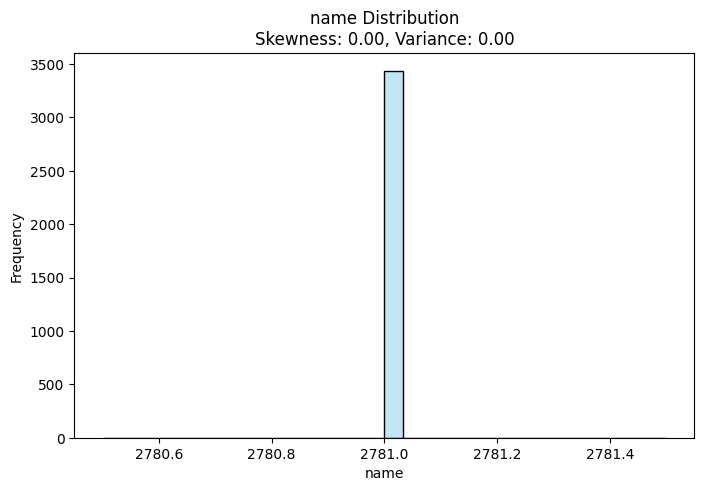

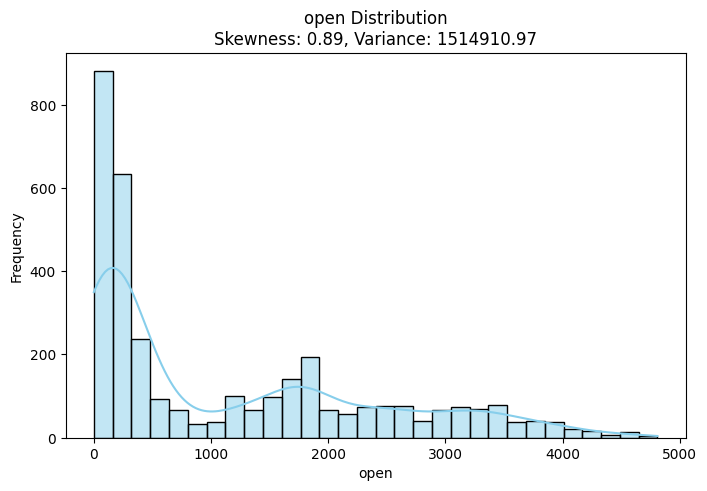

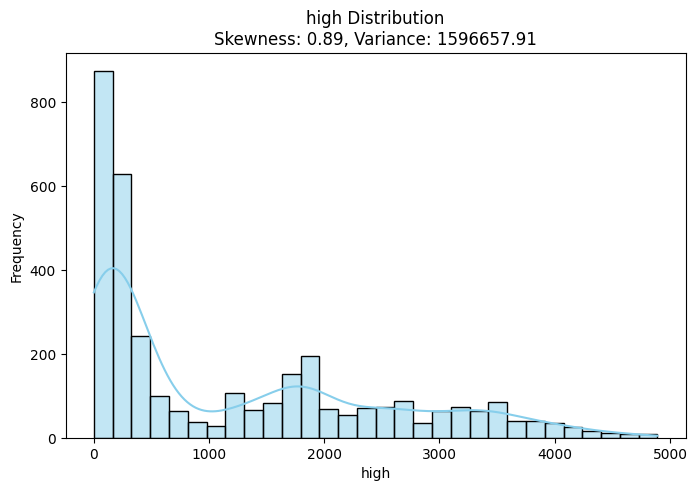

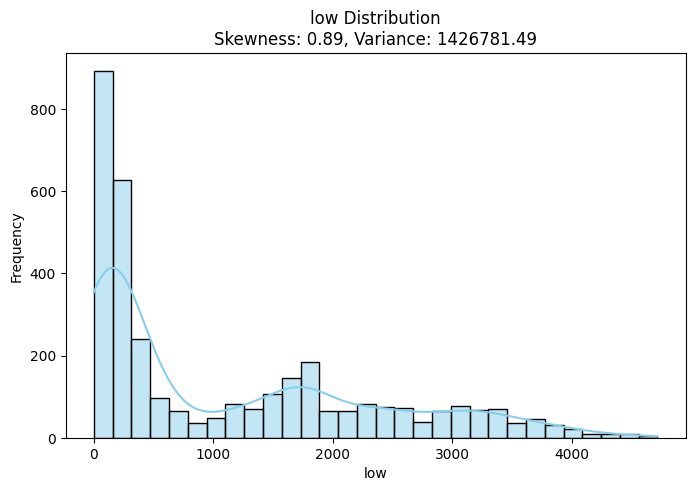

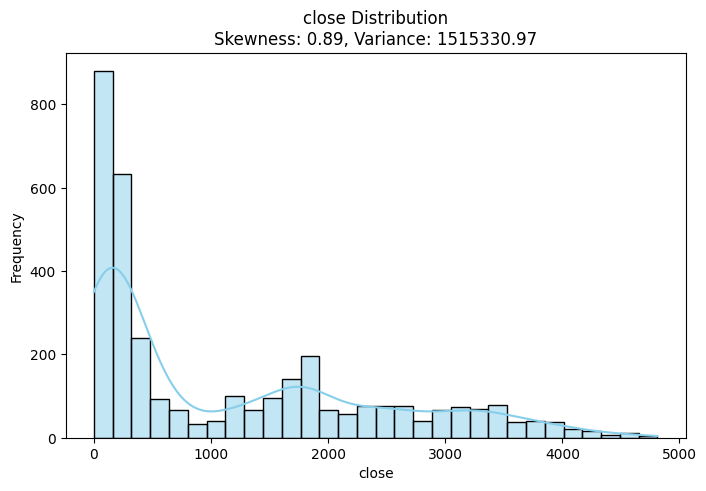

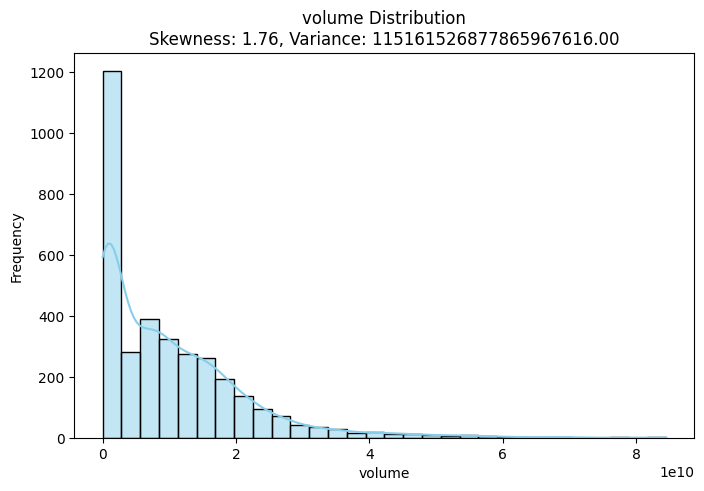

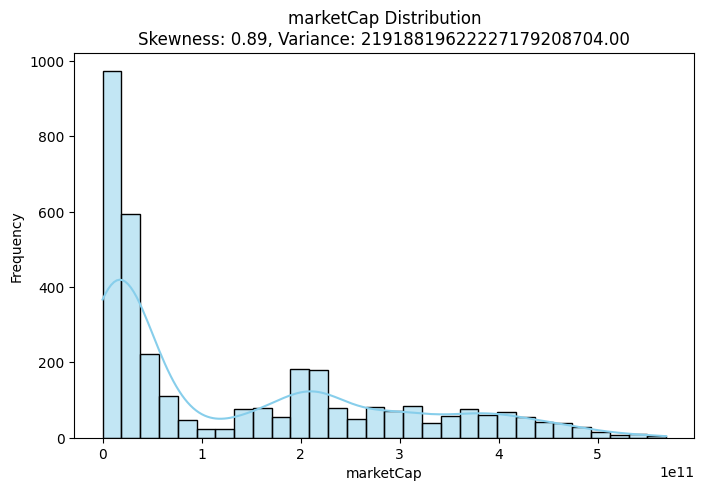

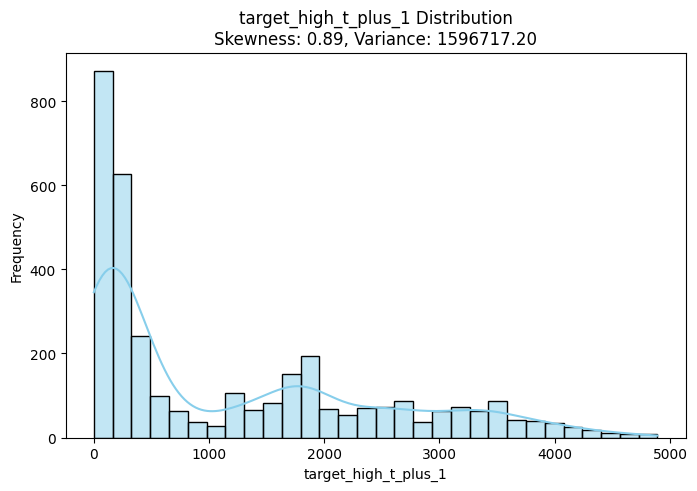

In [1012]:
#drop name
numeric_cols = unioned_df.select_dtypes(include='number').columns

for col in numeric_cols:
    skew_val = unioned_df[col].skew()
    var_val = unioned_df[col].var()
    
    plt.figure(figsize=(8,5))
    sns.histplot(unioned_df[col], bins=30, kde=True, color="skyblue")
    plt.title(f'{col} Distribution\nSkewness: {skew_val:.2f}, Variance: {var_val:.2f}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [1013]:
df.head()

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,timestamp,target_high_t_plus_1
0,2015-12-31T00:00:00.000Z,2015-12-31T23:59:59.999Z,2015-12-31T04:24:27.000Z,2015-12-31T00:09:27.000Z,2781,0.912098,0.975414,0.910277,0.933542,663994.0,7.085802e+07,2015-12-31T23:59:59.999Z,0.941099
1,2015-12-30T00:00:00.000Z,2015-12-30T23:59:59.999Z,2015-12-30T20:34:30.000Z,2015-12-30T02:09:28.000Z,2781,0.874258,0.941099,0.866647,0.911958,604078.0,6.919677e+07,2015-12-30T23:59:59.999Z,0.873054
2,2015-12-29T00:00:00.000Z,2015-12-29T23:59:59.999Z,2015-12-29T23:59:28.000Z,2015-12-29T09:09:26.000Z,2781,0.843835,0.873054,0.833232,0.873054,215742.0,6.622290e+07,2015-12-29T23:59:59.999Z,0.872394
3,2015-12-28T00:00:00.000Z,2015-12-28T23:59:59.999Z,2015-12-28T03:59:25.000Z,2015-12-28T20:59:26.000Z,2781,0.856356,0.872394,0.832932,0.845005,235134.0,6.407428e+07,2015-12-28T23:59:59.999Z,0.861538
4,2015-12-27T00:00:00.000Z,2015-12-27T23:59:59.999Z,2015-12-27T02:54:27.000Z,2015-12-27T16:29:26.000Z,2781,0.853166,0.861538,0.841151,0.856365,164565.0,6.491392e+07,2015-12-27T23:59:59.999Z,0.897453


In [1014]:
# <Student to fill this section>
feature_1_insights = """
The feature set consists of numeric price and volume metrics for Ethereum, with no missing or duplicate values, ensuring data quality and reliability. All features exhibit a heavily right-skewed distribution (skewness ≈ 0.89) and high variance, which is consistent with the volatile nature of cryptocurrency markets. Price-related features show a steady increase over time, reflecting Ethereum’s significant growth from the start to the end of the timeframe. Among the features, trading volume has the highest variance, indicating large fluctuations in daily trading activity. This highlights Ethereum’s popularity and active market participation, as high trading volumes are often associated with increased liquidity and investor interest. Overall, while the features are clean and consistent, their extreme variability and skewness pose challenges for modeling, requiring algorithms capable of handling wide-ranging and non-linear data patterns.
"""

In [1015]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `timeHigh, timeLow, timeOpen and timeClose`

In [1016]:
# Convert timestamps to datetime and extract date
for col in ["timeHigh", "timeLow", "timeOpen", "timeClose"]:
    df[col + "_date"] = pd.to_datetime(df[col]).dt.date

# Check if all 4 date columns are equal for each row
df["dates_consistent"] = (
    (df["timeHigh_date"] == df["timeLow_date"]) &
    (df["timeHigh_date"] == df["timeOpen_date"]) &
    (df["timeHigh_date"] == df["timeClose_date"])
)

print("All rows consistent:", df["dates_consistent"].all())
print("Rows with inconsistency:", df[~df["dates_consistent"]]) 


All rows consistent: False
Rows with inconsistency:                       timeOpen                 timeClose  \
2355  2022-12-14T00:00:00.000Z  2022-12-14T23:59:59.999Z   
2447  2022-09-13T00:00:00.000Z  2022-09-13T23:59:59.999Z   
2977  2023-04-01T00:00:00.000Z  2023-04-01T23:59:59.999Z   

                      timeHigh                   timeLow  name         open  \
2355  2022-12-14T18:41:00.000Z  2022-12-15T01:59:00.000Z  2781  1320.688629   
2447  2022-09-13T12:31:00.000Z  2022-09-14T00:22:00.000Z  2781  1713.962556   
2977  2023-04-01T02:02:00.000Z  2023-04-02T02:19:00.000Z  2781  1821.704354   

             high          low        close        volume     marketCap  \
2355  1346.174483  1288.558221  1288.558221  8.134742e+09  1.576859e+11   
2447  1745.779019  1564.031835  1580.787953  2.306682e+10  1.934223e+11   
2977  1840.173109  1811.118477  1813.860559  5.556444e+09  2.184936e+11   

                     timestamp  target_high_t_plus_1 timeHigh_date  \
2355  2022-12-14T23

In [1017]:
df.shape

(3433, 18)

In [1018]:
df = df.drop(columns=[
    "timeHigh_date", "timeLow_date", "timeOpen_date", "timeClose_date", "dates_consistent","timeOpen","timeClose"
])

In [1019]:
# <Student to fill this section>
feature_2_insights = """
The selected time-related features are critical for aligning cryptocurrency price and volume data over a consistent timeline. Upon inspection, all time columns are generally consistent with some skipped dates (specially for 2015 data) except for timeLow, which shows noticeable inconsistencies and irregularities with the other time columns. These discrepancies could introduce errors or misalignment when associating historical prices with timestamps, potentially affecting model accuracy. The other time columns remain consistent, providing a reliable basis for temporal analysis. To ensure data integrity, I will split the dataset based on the consistent time columns, excluding timeLow from computations.

"""

In [1020]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `Name`


In [1021]:
df.drop(columns=["name"], inplace=True)

In [1022]:
# <Student to fill this section>
feature_n_insights = """
The name column contains only a single unique value, “2781,” across all records, providing no variability or meaningful information for analysis. Since it does not contribute to the predictive power of the model, it is dropped from the dataset to reduce redundancy and maintain model efficienc
"""

In [1023]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

### C.8 Explore Feature of Interest `open, high, low, close, volume, marketCap`

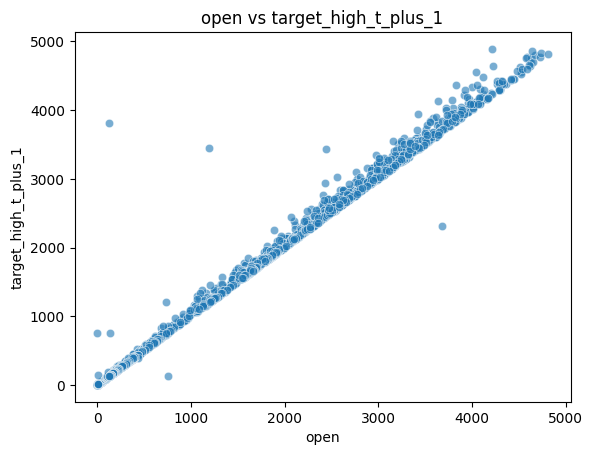

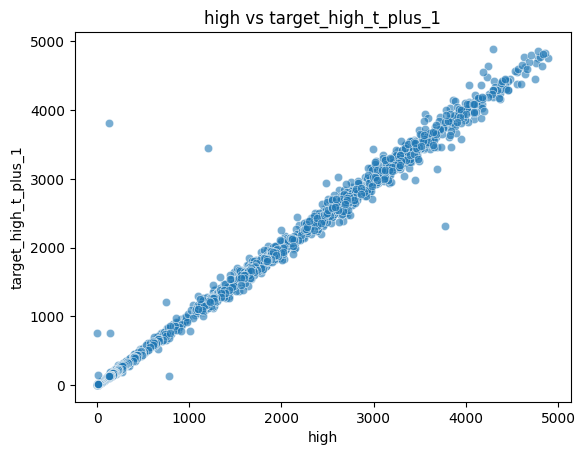

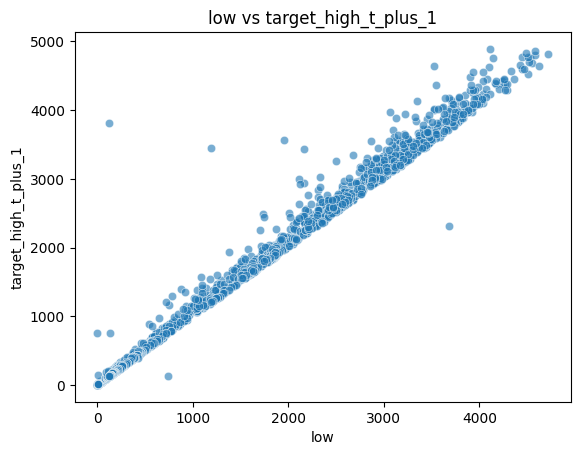

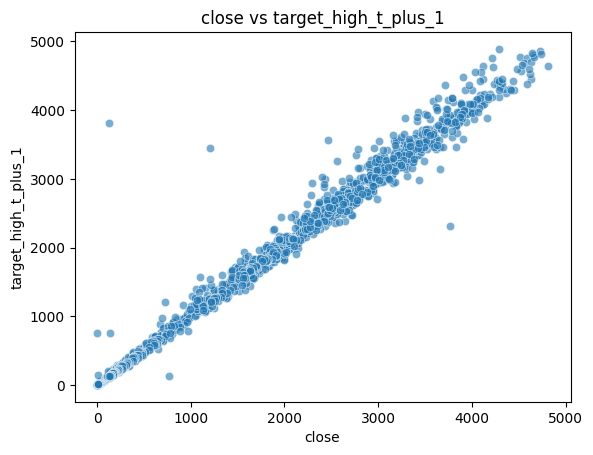

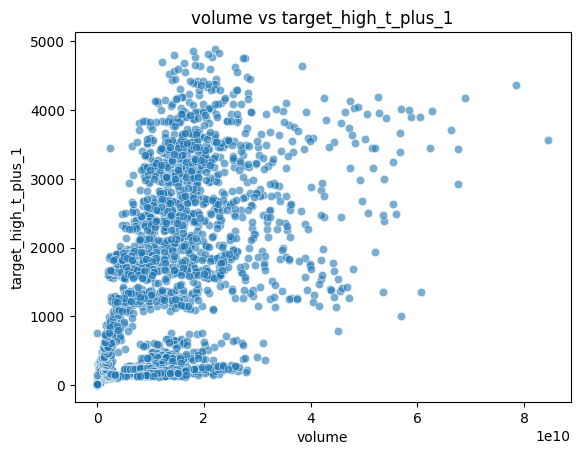

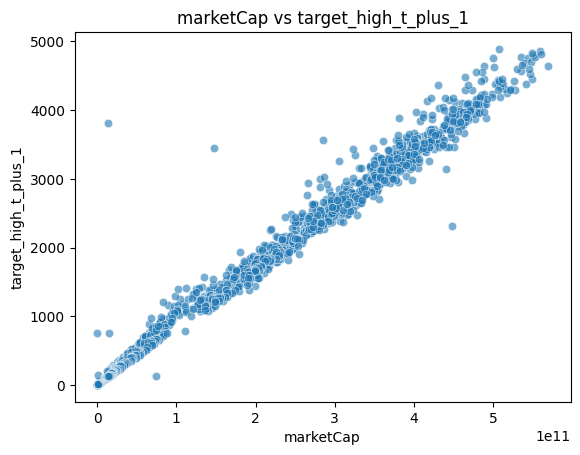

In [1024]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop(target_name)

for col in numeric_cols:
    sns.scatterplot(data=df, x=col, y=target_name, alpha=0.6)
    plt.title(f"{col} vs {target_name}")
    plt.show()

In [1025]:
# <Student to fill this section>
feature_n1_insights = """
All the price-related features and market capitalization show a strong linear relationship with the target variable, indicating that as these features increase, the next day’s high price tends to rise proportionally. This suggests that linear models, such as Linear Regression, may perform well in capturing the general trends observed in the historical data. However, the linear relationship also presents limitations, as it may fail to capture sudden market spikes or extreme peaks that are common in cryptocurrency trading and will show false relations due to multicolinearity. These abrupt fluctuations are often driven by external factors like market sentiment, regulatory news, or investor speculation, which linear models might not handle effectively. Therefore, depending on the performance of the initial linear model, it may be necessary to explore more complex non-linear algorithms, such as tree-based or ensemble methods, to better capture the full dynamics of cryptocurrency price movements.
"""

In [1026]:
# Do not modify this code
print_tile(size="h3", key='feature_n1_insights', value=feature_n1_insights)

---
## D. Feature Engineering

### D.1 New Feature "Daily return and log Daily return"

In [1027]:
df = df.sort_values("timeHigh").reset_index(drop=True)

In [1028]:
df["daily_return"] = df["close"].pct_change()
df["logret1"] = np.log(df["close"]).diff()

In [1029]:
df['daily_return'].head()

0         NaN
1   -0.068268
2    0.009333
3    0.507323
4    0.140075
Name: daily_return, dtype: float64

In [1030]:
df['logret1'].head()

0         NaN
1   -0.070710
2    0.009290
3    0.410335
4    0.131094
Name: logret1, dtype: float64

In [1031]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Creating the daily return and log return features is important because they capture the relative and percentage-based price movements of the cryptocurrency over time, providing deeper insight into market volatility and momentum. Sorting the dataset by timeHigh ensures the calculations reflect true chronological price changes. The daily_return feature measures the simple percentage change in closing prices, which helps quantify short-term gains or losses. In contrast, logret1 (logarithmic return) smooths out extreme fluctuations and is more suitable for modeling continuous price growth patterns. These features are crucial for detecting trends, understanding risk, and improving the predictive power of machine learning models.
"""

In [1032]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### D.2 New Feature "Range"

In [1033]:
df["rsi14"] = (
    lambda s: (lambda up, dn: 100 - 100/(1 + (up/dn).replace(0, np.nan)))(
        s.clip(lower=0).rolling(14).mean(),
        (-s.clip(upper=0)).rolling(14).mean()
    )
)(df["close"].diff())

In [1034]:
# <Student to fill this section>
feature_engineering_2_explanations = """
The RSI (Relative Strength Index) feature is created to capture the momentum and strength of price movements over a 14-day period, offering valuable insight into market sentiment and potential trend reversals. It measures the balance between recent gains and losses, producing values between 0 and 100—where readings above 70 typically indicate overbought conditions and values below 30 suggest oversold conditions. Including rsi14 helps the model detect periods of excessive buying or selling pressure, which are often followed by price corrections or rebounds. This feature is particularly important in cryptocurrency markets, where momentum-driven trading is common. By incorporating RSI, the model gains the ability to better identify short-term shifts in price dynamics, improving the accuracy of next-day high price predictions.
"""

In [1035]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### D.3 New Feature "high : close and high : open"

In [1036]:
df["ratio_hc"] = df["high"]/df["close"] 

In [1037]:
df["ratio_ho"] = df["high"]/df["open"] 

In [1038]:
# <Student to fill this section>
feature_engineering_n_explanations = """
The ratio_hc and ratio_ho features are created to measure the relative price movement within each trading period, providing insights into market volatility and intraday dynamics. The ratio_hc feature compares the highest price of the day to the closing price, indicating how much the price declined from its peak by the end of the trading session. Similarly, ratio_ho compares the high to the opening price, showing the magnitude of upward movement during the day.
"""

In [1039]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### D.4 New Feature "Rolling avgs and difference features"

In [1040]:
df["sma7"] = df["close"].rolling(7).mean()

In [1041]:
for col in ["open","high","close","low"]:
    df[f"{col}_diff1"] = df[col] - df[col].shift(1)

In [1042]:
# <Student to fill this section>
feature_engineering_n1_explanations = """
The 7-day Simple Moving Average (SMA7) and first-order difference features are designed to capture short-term trends and daily price momentum in the cryptocurrency market. The sma7 feature smooths out daily price fluctuations by averaging the closing prices over a 7-day window, providing a clearer view of the underlying trend. Meanwhile, the difference features measure day-to-day changes in each price variable, highlighting recent shifts in market direction and volatility.
"""

In [1043]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n1_explanations', value=feature_engineering_n1_explanations)

### D.5 New Feature "True range"

In [1044]:
df["true_range"] = (df["high"] - df["low"]).combine(
    (df["high"] - df["close"].shift(1)).abs(), max
).combine((df["low"] - df["close"].shift(1)).abs(), max)

In [1045]:
# <Student to fill this section>
feature_engineering_n2_explanations = """
The true_range feature is created to measure market volatility by capturing the most significant price movement within and across consecutive trading days. It accounts not only for the difference between the day’s high and low prices but also for price gaps between the current and previous day’s closing values.
"""

In [1046]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n2_explanations', value=feature_engineering_n2_explanations)

### D.6 Fixing "Drop nan rows after rolling and pct features"

In [1047]:
df.isnull().sum()

timeHigh                 0
timeLow                  0
open                     0
high                     0
low                      0
close                    0
volume                   0
marketCap                0
timestamp                0
target_high_t_plus_1     0
daily_return             1
logret1                  1
rsi14                   14
ratio_hc                 0
ratio_ho                 0
sma7                     6
open_diff1               1
high_diff1               1
close_diff1              1
low_diff1                1
true_range               0
dtype: int64

In [1048]:
df = df.dropna(axis=0)

In [1049]:
# <Student to fill this section>
feature_engineering_n3_explanations = """
Dropping NaNs created due to feature engineering. Models cannot handle NaNs and since these are created due to shifts, they are needed to be dropped."""

In [1050]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n3_explanations', value=feature_engineering_n3_explanations)

---
## E. Feature Selection


### E.1 Approach "Multicolinearity"


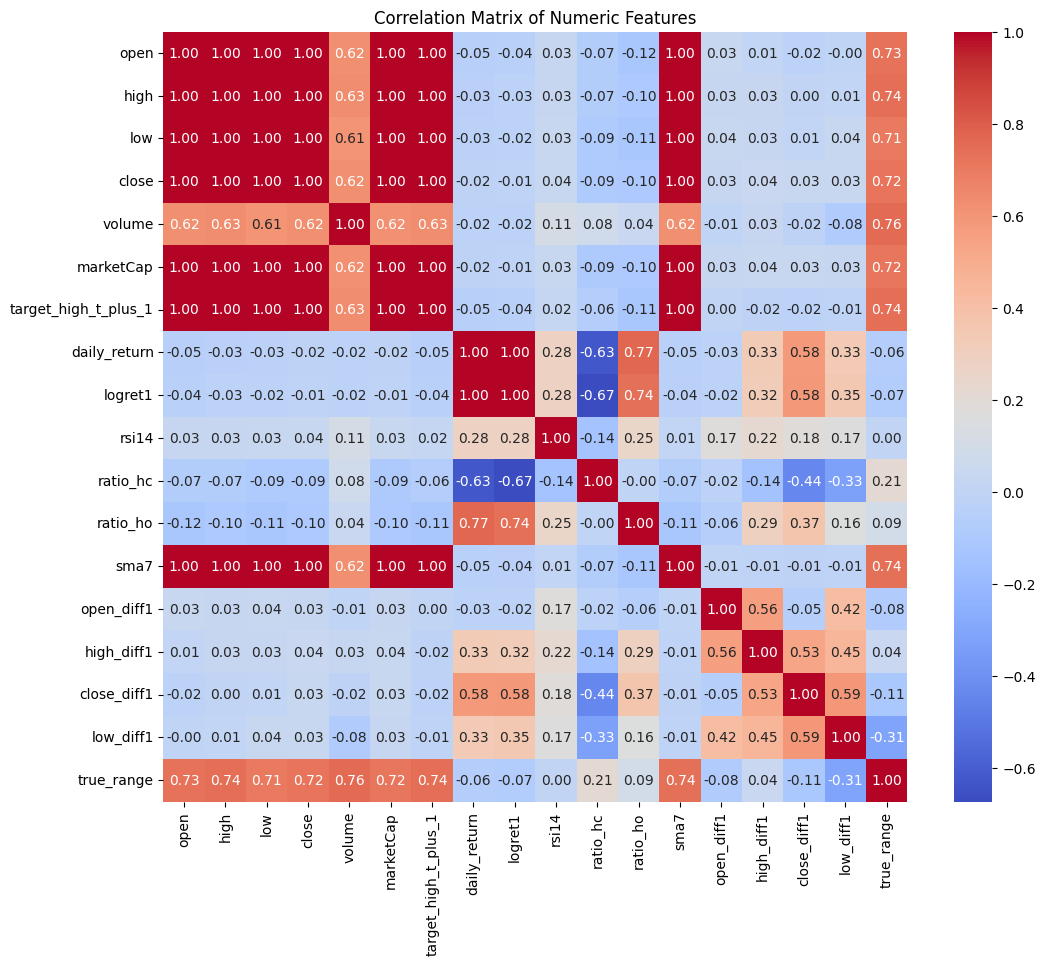

Pairs of highly correlated features (>0.8):
open <-> high : 0.9993583583984702
open <-> low : 0.9987890845953141
open <-> close : 0.9984012861446621
open <-> marketCap : 0.997904416276121
open <-> target_high_t_plus_1 : 0.997203931363418
open <-> sma7 : 0.998242444253365
high <-> low : 0.9985647393064606
high <-> close : 0.9992297911353367
high <-> marketCap : 0.9984765535280076
high <-> target_high_t_plus_1 : 0.9969325951709971
high <-> sma7 : 0.9980874674639411
low <-> close : 0.999170526640635
low <-> marketCap : 0.9989583988184555
low <-> target_high_t_plus_1 : 0.9955611928661192
low <-> sma7 : 0.9969210077067234
close <-> marketCap : 0.9994350255409976
close <-> target_high_t_plus_1 : 0.9957019919487489
close <-> sma7 : 0.9971618188710619
marketCap <-> target_high_t_plus_1 : 0.9950690157709571
marketCap <-> sma7 : 0.9967952100463958
target_high_t_plus_1 <-> sma7 : 0.9968259453320889
daily_return <-> logret1 : 0.9968141963321451


In [1051]:
numeric_cols = df.select_dtypes(include="number").columns
df_numeric = df[numeric_cols]

# Compute correlation matrix
corr_matrix = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

strong_corrs = corr_matrix.abs() > 0.8
print("Pairs of highly correlated features (>0.8):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if strong_corrs.iloc[i, j]:
            print(corr_matrix.columns[i], "<->", corr_matrix.columns[j], 
                  ":", corr_matrix.iloc[i, j])

In [1052]:
# <Student to fill this section>
feature_selection_1_insights = """
The feature selection approach targets multicollinearity to improve linear model stability, as highly correlated features can distort coefficients and obscure true relationships. While linear models benefit from reducing redundancy, tree-based models handle correlated features well, allowing them to capture complex patterns without feature removal.
"""

In [1053]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### E.2 Approach "Correlation"


In [1054]:
numeric_cols = df.select_dtypes(include="number").columns

# Ensure target is numeric and included
if target_name not in numeric_cols:
    numeric_cols = numeric_cols.append(pd.Index([target_name]))

# Compute correlations with target
corr_target = df[numeric_cols].corr()[target_name].sort_values(ascending=False)
print(corr_target)

target_high_t_plus_1    1.000000
open                    0.997204
high                    0.996933
sma7                    0.996826
close                   0.995702
low                     0.995561
marketCap               0.995069
true_range              0.739122
volume                  0.629417
rsi14                   0.022403
open_diff1              0.003687
low_diff1              -0.010464
high_diff1             -0.015134
close_diff1            -0.020830
logret1                -0.040754
daily_return           -0.048676
ratio_hc               -0.062830
ratio_ho               -0.114464
Name: target_high_t_plus_1, dtype: float64


In [1055]:
# <Student to fill this section>
feature_selection_1n_insights = """
The feature selection approach uses absolute correlation to identify the variables most strongly associated with the target, ensuring that linear models focus on the features with the greatest predictive power. As expected from the EDA scatter plots, open, high, close, low, and marketCap show the highest correlations with the next-day high price.
"""

In [1056]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1n_insights', value=feature_selection_1n_insights)

### E.3 Approach "RFE"


In [1057]:
X = df.drop(columns=[target_name])

# Target
y = df[target_name]

# Keep only numeric features in X
X_numeric = X.select_dtypes(include="number")

# RFE
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

estimator = LinearRegression()
selector = RFE(estimator, n_features_to_select=15, step=1)
selector.fit(X_numeric, y)

selected_features = X_numeric.columns[selector.support_]
print("Selected numeric features:", selected_features)

Selected numeric features: Index(['open', 'high', 'low', 'close', 'daily_return', 'logret1', 'rsi14',
       'ratio_hc', 'ratio_ho', 'sma7', 'open_diff1', 'high_diff1',
       'close_diff1', 'low_diff1', 'true_range'],
      dtype='object')


In [1058]:
# <Student to fill this section>
feature_selection_2_insights = """
Recursive Feature Elimination (RFE) was applied to select features because it systematically evaluates each feature’s contribution, allowing both linear and non-linear models to capture the most relevant patterns. Using RFE, the selected features—open, high, low, daily_return, logret1, rsi14, ratio_hc, ratio_ho, sma7, open_diff1, high_diff1, close_diff1, low_diff1, true_range, and range—represent a balance of price levels, momentum, volatility, and technical indicators, ensuring the models retain information about both trend-following and short-term fluctuations for accurate next-day high price predictions.
"""

In [1059]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### E.4 Approach "LightGBMRegressor selection"

In [1060]:
X_numeric = X.select_dtypes(include="number")

# Define LightGBM regressor
lgb_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Fit the model
lgb_model.fit(X_numeric, y)

# Get feature importances
importances = pd.Series(lgb_model.feature_importances_, index=X_numeric.columns)
importances = importances.sort_values(ascending=False)

print(importances)

open            414
high_diff1      363
open_diff1      289
high            267
sma7            229
ratio_hc        212
true_range      203
volume          180
rsi14           149
ratio_ho        129
close_diff1     126
close            99
daily_return     95
low              89
low_diff1        86
marketCap        70
logret1           0
dtype: int32


In [1061]:
# <Student to fill this section>
feature_selection_2n_insights = """
LightGBM feature selection was applied because the model itself can naturally rank feature importance based on how much each variable contributes to reducing error in the tree splits. The top features identified highlight the most influential predictors for next-day high price, capturing both price levels and momentum patterns that LightGBM leverages effectively for accurate forecasting."""

In [1062]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2n_insights', value=feature_selection_2n_insights)

## E.z Final Selection of Features

In [1063]:
features_list_linear = [
    "timeHigh",
    "open",
    "marketCap",                   
    "daily_return",
    "true_range",
    "rsi14",
    "ratio_hc",
    "ratio_ho",
    "high_diff1",
    "close_diff1",
    "target_high_t_plus_1"]

df_linear = df[features_list_linear]

In [1064]:
features_list_tree = [
    "timeHigh",
    'open', 
    'high_diff1', 
    'open_diff1', 
    'sma7',
    'ratio_hc', 
    'volume', 
    'true_range', 
    'rsi14',
    'ratio_ho',
    'marketCap',
    'daily_return',
    'target_high_t_plus_1']
df_tree = df[features_list_tree]

In [1065]:
# <Student to fill this section>
feature_selection_explanations = """
The selected features combine insights from multiple approaches: for linear models, features were chosen using absolute correlation and RFE to capture the most predictive variables while minimizing multicollinearity; for tree-based models, RFE and LightGBM feature importance were used to retain variables that capture both linear and non-linear patterns. This ensures that each model uses the features most relevant to its strengths, balancing interpretability, predictive power, and robustness.
"""

In [1066]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## F. Data Preparation

### F.1 Data Transformation "Log1p for volume"

In [1067]:
df_tree['volume_log'] = np.log1p(df_tree['volume'])

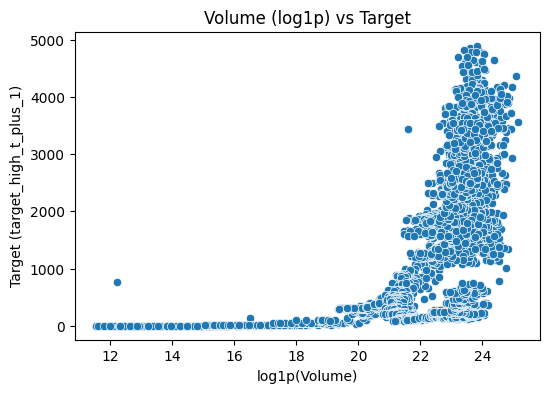

In [1068]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df_tree['volume_log'], y=df_tree['target_high_t_plus_1'])
plt.title('Volume (log1p) vs Target')
plt.xlabel('log1p(Volume)')
plt.ylabel('Target (target_high_t_plus_1)')
plt.show()

In [1069]:
numeric_cols = df_tree.select_dtypes(include='number').columns.tolist()

# Drop target and volume_log
X = df_tree[numeric_cols].drop(columns=['target_high_t_plus_1', 'volume_log'], errors='ignore')
y = df_tree['target_high_t_plus_1']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit LightGBM
model = LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top features:")
print(importances.head(10))

# Check importance of volume_log if it exists
print(f"\nlog1p(Volume) importance: {importances.get('volume_log', 0)}")

Top features:
open          626
high_diff1    344
ratio_hc      339
open_diff1    288
sma7          274
volume        235
rsi14         234
marketCap     229
true_range    181
ratio_ho      169
dtype: int32

log1p(Volume) importance: 0


In [1070]:
df_tree=df[features_list_tree]

In [1071]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Transforming the volume feature with log1p was attempted to reduce skewness and potentially improve correlation with the target. However, the transformation diminished its predictive value for the tree-based model, as raw volume better captures large fluctuations and market activity that influence price movements. Retaining the original volume.
"""

In [1072]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [1073]:
# Ensure 'timeHigh' is datetime
for df in [df_linear, df_tree]:
    df['timeHigh'] = pd.to_datetime(df['timeHigh'])

# Define cutoff date 
cutoff_date = pd.to_datetime("2023-08-01").date()

# Function to split based on date only
def time_split(df, date_col, cutoff):
    train = df[df[date_col].dt.date < cutoff].copy()
    test = df[df[date_col].dt.date >= cutoff].copy()
    return train, test

# Split both datasets
linear_train, linear_test = time_split(df_linear, 'timeHigh', cutoff_date)
tree_train, tree_test = time_split(df_tree, 'timeHigh', cutoff_date)

print("Linear train/test shapes:", linear_train.shape, linear_test.shape)
print("Tree train/test shapes:", tree_train.shape, tree_test.shape)

Linear train/test shapes: (2901, 11) (518, 11)
Tree train/test shapes: (2901, 13) (518, 13)


In [1074]:
# Linear dataset
linear_train = linear_train.drop(columns=['timeHigh'])
linear_test = linear_test.drop(columns=['timeHigh'])

# Tree dataset
tree_train = tree_train.drop(columns=['timeHigh'])
tree_test = tree_test.drop(columns=['timeHigh'])

In [1075]:
# <Student to fill this section>
data_splitting_explanations = """
The best strategy for splitting this cryptocurrency dataset is a temporal (time-based) split, as done here, because the data is almost sequential. Using data from 2015 up to just before 2023-08-01 for training and reserving 2023-08-01 to the end of 2024 for testing ensures that the model learns from historical trends and is evaluated on truly unseen future data. This approach prevents data leakage, maintains the chronological order of events, and provides a realistic assessment of how well the model can predict next-day highs in live trading scenarios.
"""

In [1076]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

---
## H. Save Datasets

> Do not change this code

In [1077]:
# # Do not modify this code
# # Save training set
# try:
#   X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
#   y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

#   X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
#   y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

#   X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
#   y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
# except Exception as e:
#   print(e)

In [1078]:
class AttrDict:
    pass

at = AttrDict()
at.folder_path = Path("data/processed")
at.folder_path.mkdir(parents=True, exist_ok=True)

# Linear dataset
X_train = linear_train.drop(columns=['target_high_t_plus_1'])
y_train = linear_train[['target_high_t_plus_1']]

X_test = linear_test.drop(columns=['target_high_t_plus_1'])
y_test = linear_test[['target_high_t_plus_1']]

# Save Linear dataset
try:
    X_train.to_csv(at.folder_path/'X_train_linear.csv', index=False)
    y_train.to_csv(at.folder_path/'y_train_linear.csv', index=False)

    X_test.to_csv(at.folder_path/'X_test_linear.csv', index=False)
    y_test.to_csv(at.folder_path/'y_test_linear.csv', index=False)
    print("Linear dataset saved successfully.")
except Exception as e:
    print("Error saving linear dataset:", e)


# Tree dataset
X_train_tree = tree_train.drop(columns=['target_high_t_plus_1'])
y_train_tree = tree_train[['target_high_t_plus_1']]

X_test_tree = tree_test.drop(columns=['target_high_t_plus_1'])
y_test_tree = tree_test[['target_high_t_plus_1']]

# Save Tree dataset
try:
    X_train_tree.to_csv(at.folder_path/'X_train_tree.csv', index=False)
    y_train_tree.to_csv(at.folder_path/'y_train_tree.csv', index=False)

    X_test_tree.to_csv(at.folder_path/'X_test_tree.csv', index=False)
    y_test_tree.to_csv(at.folder_path/'y_test_tree.csv', index=False)
    print("Tree dataset saved successfully.")
except Exception as e:
    print("Error saving tree dataset:", e)

Linear dataset saved successfully.
Tree dataset saved successfully.


---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [1079]:
from sklearn.metrics import mean_squared_error, r2_score

In [1080]:
# <Student to fill this section>
performance_metrics_explanations = """
The chosen performance metrics, RMSE (via mean_squared_error) and R² score, are appropriate because they evaluate both the accuracy and explanatory power of the regression model. RMSE measures the average magnitude of prediction errors in the same units as the target, making it easy to interpret in a financial context. R² indicates how much of the variability in the next-day high price is captured by the model, providing insight into its overall predictive effectiveness."""

In [1081]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [1082]:
# LightGBM
from lightgbm import LGBMRegressor

# ElasticNet from scikit-learn
from sklearn.linear_model import ElasticNet

In [1083]:
# <Student to fill this section>
algorithm_selection_explanations = """
LightGBM is a good fit because it is a gradient boosting tree-based algorithm that handles non-linear relationships, interactions, and high-variance features effectively, making it well-suited for the volatile and complex nature of cryptocurrency price data. It also manages multicollinearity and missing values without extensive preprocessing, allowing the model to leverage a wide range of features like price, volume, and technical indicators.

ElasticNet is appropriate because it combines L1 and L2 regularization, making it robust to multicollinearity among linear features while performing feature selection. This makes it ideal for capturing the linear trends in price-related features and reducing overfitting, providing interpretable and stable predictions for next-day high prices.
"""

In [1084]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters


In [1085]:
en_reg = ElasticNet(
    alpha=1.0,      
    l1_ratio=0.5,     
    max_iter=1000,
    random_state=42
)

In [1086]:
lgbm_reg = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20],
    'subsample': [1.0],
    'colsample_bytree': [1.0],
    'reg_alpha': [0.0],
    'reg_lambda': [0.0],
    'objective': ['regression']
}

In [1087]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
The hyperparameters for ElasticNet are tuned to balance L1 (lasso) and L2 (ridge) regularization using alpha and l1_ratio, which helps manage multicollinearity among price-related features while preventing overfitting and selecting the most relevant variables.

For LightGBM, the chosen hyperparameters are primarily defaults because initial experiments using GridSearchCV showed that the default settings provided the best performance. These parameters control tree complexity, learning rate, and regularization, allowing the model to capture non-linear patterns and interactions in the cryptocurrency data without overfitting.
"""

In [1088]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [1089]:
en_reg = ElasticNet(random_state=42)
en_reg.fit(X_train, y_train.values.ravel())
y_pred_en_linear = en_reg.predict(X_test)

In [1090]:
# Ensure test columns match training columns
X_test_tree = X_test_tree[X_train_tree.columns]

# Initialize and fit LightGBM
lgb_model = LGBMRegressor(random_state=42)
lgb_model.fit(X_train_tree, y_train_tree.values.ravel())  # train

LGBMRegressor(random_state=42)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [1091]:
y_pred_train_linear = en_reg.predict(X_train)
y_pred_test_linear  = en_reg.predict(X_test)

# Evaluate
train_rmse_linear = mean_squared_error(y_train, y_pred_train_linear, squared=False)
train_r2_linear   = r2_score(y_train, y_pred_train_linear)

test_rmse_linear  = mean_squared_error(y_test, y_pred_test_linear, squared=False)
test_r2_linear    = r2_score(y_test, y_pred_test_linear)

print("Linear Dataset - ElasticNet Regressor:")
print("Train RMSE:", train_rmse_linear, "R2:", train_r2_linear)
print("Test  RMSE:", test_rmse_linear,  "R2:", test_r2_linear)

Linear Dataset - ElasticNet Regressor:
Train RMSE: 88.85483313184344 R2: 0.993797429518798
Test  RMSE: 17.973213891814897 R2: 0.999387685907827


In [1092]:
# Predict on training and test sets
y_pred_train_tree = lgb_model.predict(X_train_tree)
y_pred_test_tree  = lgb_model.predict(X_test_tree)

# Evaluate
train_rmse_tree = mean_squared_error(y_train_tree, y_pred_train_tree, squared=False)
train_r2_tree   = r2_score(y_train_tree, y_pred_train_tree)

test_rmse_tree  = mean_squared_error(y_test_tree, y_pred_test_tree, squared=False)
test_r2_tree    = r2_score(y_test_tree, y_pred_test_tree)

print("\nTree Dataset - LightGBM Regressor:")
print("Train RMSE:", train_rmse_tree, "R2:", train_r2_tree)
print("Test  RMSE:", test_rmse_tree,  "R2:", test_r2_tree)


Tree Dataset - LightGBM Regressor:
Train RMSE: 61.474923688211504 R2: 0.9970310314762949
Test  RMSE: 55.46276700267663 R2: 0.9941692310260898


In [1093]:
# <Student to fill this section>
model_performance_explanations = """
The model performance shows that both ElasticNet and LightGBM are able to predict next-day high prices effectively, with strong explanatory power and low prediction error.ElasticNet appears to perform exceptionally well on both train and test sets, but this performance may be misleading. The high scores are likely influenced by the strong multicollinearity among the features and the high variance in the target, which allows the model to “memorize” trends in the data rather than genuinely generalize. In reality, while ElasticNet captures linear relationships effectively, its seemingly perfect performance may overstate its predictive reliability, especially under changing market conditions or on truly unseen data.LightGBM also performs very well, capturing non-linear patterns and interactions, demonstrating its robustness to volatility in cryptocurrency data. It is notable that both models exhibit lower test RMSE compared to earlier periods; this is likely due to the temporal split and the fact that recent Ethereum prices are much higher than older values, causing prediction errors on older data to appear larger while errors on newer, higher-value data are proportionally smaller. Overall, both models provide reliable forecasts, with ElasticNet slightly misleading due to the linear relationships and multicollinearity handling.
"""

In [1094]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Save the Best Model (LGBM) , Feature Engineering and Feature selection for FastAPI
> Provide some explanations on model performance


In [1095]:
import json
# 1) Save your trained model
joblib.dump(lgb_model, 'models/lgb_model.joblib')
print("Model saved!")

# 2) Save your feature list (exact order used in training)
FEATURES_TREE = [
    'open', 
    'high_diff1', 
    'open_diff1', 
    'sma7',
    'ratio_hc', 
    'volume', 
    'true_range', 
    'rsi14',
    'ratio_ho',
    'marketCap',
    'daily_return'
]

with open('models/features.json', 'w') as f:
    json.dump(FEATURES_TREE, f, indent=2)
print("Feature list saved!")

# 3) Save preprocessing function (for FastAPI)

def preprocess_features(df):
    """
    Replicate exact feature engineering from training.
    Returns DataFrame with features only, nulls dropped.
    """
    df = df.copy()
    
    # Your exact FE code
    df["daily_return"] = df["close"].pct_change()
    df["logret1"] = np.log(df["close"]).diff()
    
    df["rsi14"] = (
        lambda s: (lambda up, dn: 100 - 100/(1 + (up/dn).replace(0, np.nan)))(
            s.clip(lower=0).rolling(14).mean(),
            (-s.clip(upper=0)).rolling(14).mean()
        )
    )(df["close"].diff())
    
    df["ratio_hc"] = df["high"]/df["close"] 
    df["ratio_ho"] = df["high"]/df["open"] 
    
    df["sma7"] = df["close"].rolling(7).mean()
    
    for col in ["open","high","close","low"]:
        df[f"{col}_diff1"] = df[col] - df[col].shift(1)
    
    df["true_range"] = (df["high"] - df["low"]).combine(
        (df["high"] - df["close"].shift(1)).abs(), max
    ).combine((df["low"] - df["close"].shift(1)).abs(), max)
    
    # Drop nulls (from rolling windows)
    df = df.dropna()
    
    return df

# Save preprocessing function
with open('models/preprocess_func.pkl', 'wb') as f:
    dill.dump(preprocess_features, f)
print("Preprocessing function saved!")

Model saved!
Feature list saved!
Preprocessing function saved!


### J.6 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


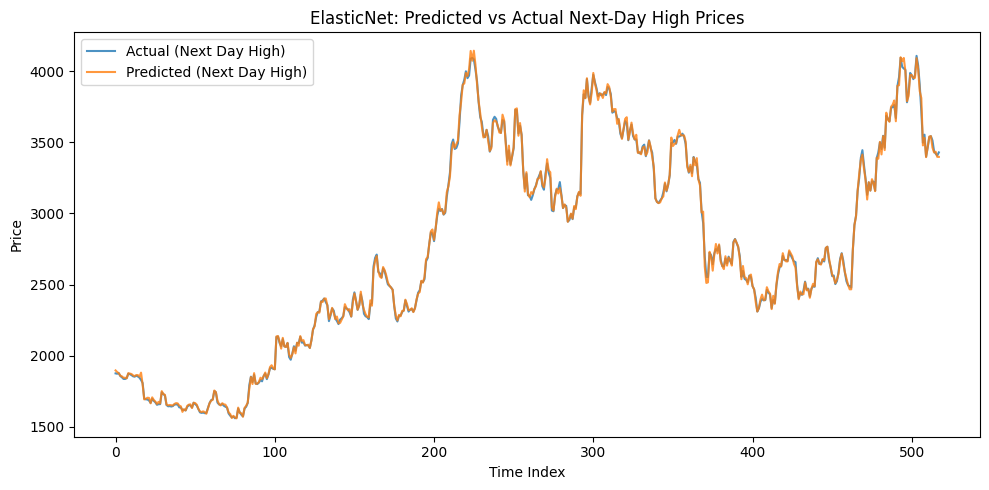

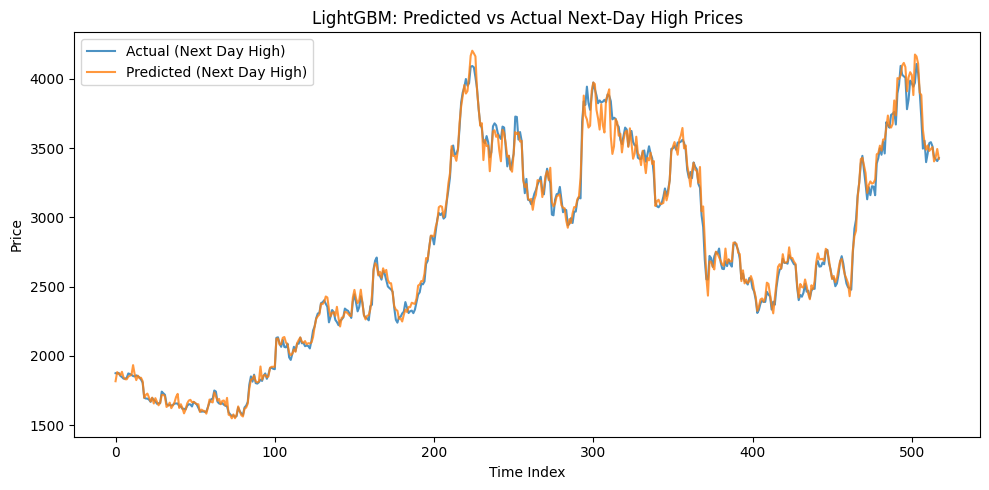

In [1097]:
# -------- Plot for ElasticNet (linear dataset) --------
x_axis = np.arange(len(y_test))
plt.figure(figsize=(10, 5))
plt.plot(x_axis, y_test, label='Actual (Next Day High)', alpha=0.8)
plt.plot(x_axis, y_pred_test_linear, label='Predicted (Next Day High)', alpha=0.8)
plt.title('ElasticNet: Predicted vs Actual Next-Day High Prices')
plt.xlabel('Time Index')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# -------- Plot for LightGBM (tree dataset) --------
x_axis_tree = np.arange(len(y_test_tree))
plt.figure(figsize=(10, 5))
plt.plot(x_axis_tree, y_test_tree, label='Actual (Next Day High)', alpha=0.8)
plt.plot(x_axis_tree, y_pred_test_tree, label='Predicted (Next Day High)', alpha=0.8)
plt.title('LightGBM: Predicted vs Actual Next-Day High Prices')
plt.xlabel('Time Index')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

In [1098]:
# <Student to fill this section>
business_impacts_explanations = """
The experiments show that both ElasticNet and LightGBM can predict next-day high prices for cryptocurrencies with high apparent accuracy, supporting the business objective of providing investors with actionable insights. Accurate predictions allow users to make more informed trading decisions, potentially increasing returns and reducing exposure to short-term market volatility. However, incorrect predictions carry varying levels of risk: misestimating extreme highs or sudden spikes could lead to substantial financial losses for investors, particularly in a volatile market like Ethereum, where price swings can be dramatic. ElasticNet’s seemingly perfect fit may be misleading due to multicollinearity and high target variance, meaning users relying solely on it could be misled under changing market conditions. LightGBM, while robust to non-linear patterns and feature interactions, could still underperform during sudden market shocks. Overall, incorrect predictions could undermine user trust and lead to financial losses, highlighting the importance of clear communication of model limitations and uncertainty to end users."""

In [1099]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [1100]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [1101]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [1102]:
# <Student to fill this section>
experiment_results_explanations = """
The initial hypothesis was that both linear and tree-based models could effectively predict next-day high prices for cryptocurrencies, and the results largely confirm this, as evidenced by the low test RMSE values, which indicate strong predictive performance on unseen data. Reflecting on the experiments, several insights emerged: ElasticNet’s seemingly perfect performance can be misleading due to multicollinearity and high variance in the target, whereas LightGBM reliably captures both linear and non-linear relationships, making it more robust for volatile market conditions. This suggests that while the current modeling approach is promising, further experimentation could focus on incorporating additional features such as sentiment indicators, macroeconomic factors, or other technical indicators to improve prediction during extreme market movements. Potential next steps include hyperparameter tuning with larger search spaces, ensemble modeling to combine linear and tree-based predictions, and testing on different temporal splits to evaluate generalization. Expected gains from these steps include improved accuracy during volatile periods and better handling of extreme peaks, with ensemble methods likely offering the highest uplift. Given the satisfactory performance achieved, particularly by LightGBM, the solution is suitable for deployment into production, with recommendations to include monitoring for model drift and periodic retraining to maintain reliability as market conditions evolve."""

In [1103]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)